# AI-Powered Smart Attendance Management and Certificate Eligibility Prediction System Using Zoom Data

## Problem Statement

Manual attendance tracking is time-consuming and error-prone. Students may join and leave multiple times during a session. This project processes Zoom attendance records and predicts certificate eligibility automatically.

## Introduction

Online classes generate large attendance records which are difficult to analyze manually. This project automates attendance analysis and predicts certificate eligibility using Machine Learning.

## Objectives

- Process Zoom attendance data
- Handle multiple join and leave sessions correctly
- Calculate attendance percentage
- Determine certificate eligibility
- Train a Machine Learning model
- Evaluate model performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Data Collection

In [9]:
df = pd.read_csv("zoom_attendance.csv")
df.columns = df.columns.str.strip()
df.head()

,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,Department,Group,Source,Unique viewers,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Data Analysis using Python - Summer Online Int...,Meeting,932 5001 3841,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,1,1,Operations,NaN,Zoom,-,-,05/05/2026 11:06:38 AM,santosh s (Host),venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,No,NaN,No
1,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,Operations,NaN,Zoom,-,-,05/05/2026 12:15:31 PM,Jaya Prakash Jagadam,jayaprakashjagadam7@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:10:28 PM,68,Yes,No Response,No
2,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,Operations,NaN,Zoom,-,-,05/05/2026 12:15:31 PM,Shreshta K 25BFD58007 SVCE,shreshtasudhakar@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 06:10:57 PM,8,Yes,No Response,No
3,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,Operations,NaN,Zoom,-,-,05/05/2026 12:15:31 PM,Ravilla Jeshitha,jeshitharavillajeshitha@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:50:44 PM,108,Yes,OK,No
4,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,Operations,NaN,Zoom,-,-,05/05/2026 12:15:31 PM,ABHIRAM-24B91A0345-SRKR ( JONNALAGADDA ABHIRAM ),jonnalagadda.abhiram2007@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:48:28 PM,106,Yes,OK,No


### Data Processing

In [10]:
df = df[~df["Name (original name)"].str.lower().str.contains(
    "host|co-host|organizer|panelist", na=False
)]

In [11]:
df["Duration (minutes)"] = df["Duration (minutes)"].astype(float)

In [12]:
student_attendance = df.groupby(
    ["Name (original name)", "Email"],
    as_index=False
)["Duration (minutes)"].sum()

In [13]:
session_counts = df.groupby(
    ["Name (original name)", "Email"]
).size().reset_index(name="Total Sessions")

student_attendance = student_attendance.merge(
    session_counts,
    on=["Name (original name)", "Email"],
    how="left"
)

In [28]:
total_class_duration = 120

student_attendance["Attendance %"] = (
    student_attendance["Duration (minutes)"] /
    total_class_duration
) * 100
student_attendance["Attendance %"] = (
    student_attendance["Attendance %"]
    .clip(upper=100)
    .round()
    .astype(int)
)

In [15]:
student_attendance["Eligibility"] = student_attendance["Attendance %"].apply(
    lambda x: "Eligible" if x >= 80 else "Not Eligible"
)

### Exploratory Data Analysis

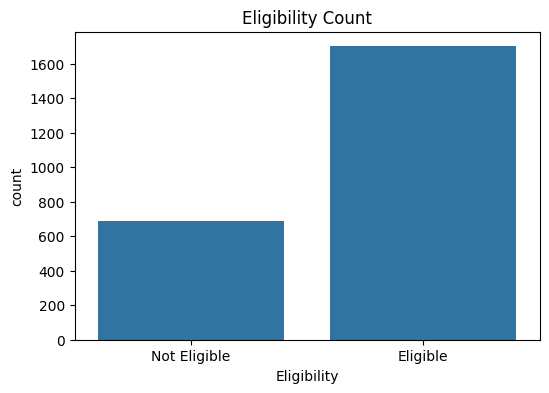

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Eligibility",
    data=student_attendance
)
plt.title("Eligibility Count")
plt.show()

### Feature Selection

In [29]:
le = LabelEncoder()
y = le.fit_transform(student_attendance["Eligibility"])

In [19]:
X = student_attendance[
    ["Duration (minutes)",
     "Total Sessions",
     "Attendance %"]
]

### Split Data into Training and Testing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Selection

In [31]:
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
y_pred = model.predict(X_test)

## Model Evaluation

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 1.0

Confusion Matrix
[[347   0]
 [  0 131]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       347
           1       1.00      1.00      1.00       131

    accuracy                           1.00       478
   macro avg       1.00      1.00      1.00       478
weighted avg       1.00      1.00      1.00       478



# Final Attendance Report

In [33]:
final_output = student_attendance.copy()
final_output["Attendance %"] = (
    final_output["Attendance %"].astype(str) + "%"
)
final_output

,Name (original name),Email,Duration (minutes),Total Sessions,Attendance %,Eligibility
0,( 24221A1209)bukkuru upendrakumar ( bukkuru up...,bukkuruupendrakumar@gmail.com,28.0,1,23%,Not Eligible
1,(23001A0522)Indira Priyadarshini ( (23001A0522...,k.indira2006@gmail.com,28.0,1,23%,Not Eligible
2,(23001A0527)N Sravani ( N Sravani ),sravanicse200@gmail.com,28.0,1,23%,Not Eligible
3,(23221A0574)Ramya Manne,ramyamanne1326@gmail.com,28.0,1,23%,Not Eligible
4,(234M1A0525) CHIRANJEEVI LALITH KUMAR-(Vemu IT),lalithkumar38879@gmail.com,122.0,1,100%,Eligible
5,(234M1A0525) CHIRANJEEVI LALITH KUMAR-(Vemu IT...,lalithkumar38879@gmail.com,122.0,1,100%,Eligible
6,(23551A4206)Satya Venkata Narasimha Aripaka,satyaaripaka19@gmail.com,28.0,1,23%,Not Eligible
7,(23551A4421)Sridevi Dendukuri ( Sridevi Denduk...,sridevidendukuri1729@gmail.com,28.0,1,23%,Not Eligible
8,(23BQ1A6185) Mattupalli Rani,ranimattupalli60@gmail.com,113.0,1,94%,Eligible
9,(23BQ1A61C1) Bhanu vighnesh,saketibhanu2005@gmail.com,28.0,1,23%,Not Eligible


In [26]:
joblib.dump(model, "attendance_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [35]:
print("Total Students :", final_output.shape[0])
eligible_count = final_output[
    final_output["Eligibility"] == "Eligible"
].shape[0]
print("Eligible Students :", eligible_count)

Total Students : 2386
Eligible Students : 1700


# Conclusion

The proposed system successfully automates attendance management and predicts certificate eligibility using Zoom attendance data. It reduces manual effort and provides accurate attendance analysis using Machine Learning techniques.